In [1]:
MODEL_NAME = "gpt2"

print("Model:", MODEL_NAME)

Model: gpt2


In [2]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

model.eval()

print("GPT-2 loaded successfully")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 loaded successfully


In [3]:
print("Number of transformer layers:", model.config.n_layer)
print("Hidden size:", model.config.n_embd)

Number of transformer layers: 12
Hidden size: 768


In [6]:
import torch

print("PyTorch version:", torch.__version__)

prompt = "The Eiffel Tower is located in the city of"

inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

next_token_id = outputs.logits[0, -1, :].argmax()
next_token = tokenizer.decode(next_token_id)

print("Prompt:", prompt)
print("Predicted next token:", repr(next_token))

PyTorch version: 2.11.0+cpu
Prompt: The Eiffel Tower is located in the city of
Predicted next token: ' Paris'


In [7]:
corrupt_prompt = "The Colosseum is located in the city of"

corrupt_inputs = tokenizer(
    corrupt_prompt,
    return_tensors="pt"
)

with torch.no_grad():
    corrupt_outputs = model(**corrupt_inputs)

corrupt_next_token_id = corrupt_outputs.logits[0, -1, :].argmax()
corrupt_next_token = tokenizer.decode(corrupt_next_token_id)

print("Corrupted prompt:", corrupt_prompt)
print("Predicted next token:", repr(corrupt_next_token))


Corrupted prompt: The Colosseum is located in the city of
Predicted next token: ' P'


In [8]:
paris_id = tokenizer.encode(" Paris")[0]

clean_probs = torch.softmax(
    outputs.logits[0, -1, :],
    dim=-1
)

corrupt_probs = torch.softmax(
    corrupt_outputs.logits[0, -1, :],
    dim=-1
)

print("P(Paris) — clean:", clean_probs[paris_id].item())
print("P(Paris) — corrupted:", corrupt_probs[paris_id].item())


P(Paris) — clean: 0.06377919763326645
P(Paris) — corrupted: 0.003861230332404375


In [9]:
with torch.no_grad():
    clean_outputs = model(**inputs, output_hidden_states=True)

print("Number of hidden-state tensors:", len(clean_outputs.hidden_states))
print("Shape of one hidden state:", clean_outputs.hidden_states[1].shape)

Number of hidden-state tensors: 13
Shape of one hidden state: torch.Size([1, 11, 768])


In [10]:
clean_layer_1 = clean_outputs.hidden_states[1][0, -1, :]

print("Shape:", clean_layer_1.shape)

Shape: torch.Size([768])


In [11]:
clean_layer_1

tensor([ 1.7784e+00,  1.0764e+00,  3.5466e-01,  1.2178e+00,  8.4376e-01,
         1.8507e-01,  1.0687e+00,  2.7409e+00, -4.2922e-01,  8.2441e-02,
        -7.8802e-02, -7.6708e-02,  2.2985e-01,  6.6382e-01, -1.4526e-01,
        -8.7224e-01, -7.1557e-02,  1.4616e-01, -1.1028e+00, -1.0520e+00,
         1.2176e-01, -7.5787e-01, -3.8840e-01,  5.8741e-01, -8.4104e-01,
         1.0588e+00,  2.6121e-01, -5.4326e-01,  5.5813e-01, -8.3503e-01,
        -2.0119e-01, -1.0215e-01, -9.7659e-01,  6.2362e-01,  2.3839e-01,
         6.8901e-01, -2.0278e+00, -1.8900e-01, -4.5349e-01,  6.8222e-01,
        -1.0490e-01, -3.7040e-02,  4.5652e-01,  9.1256e-01,  2.0446e-01,
        -7.1026e-01,  4.2649e-01,  1.8742e-01, -2.0946e+00, -5.2297e-01,
         2.1404e-02, -1.3285e-01,  1.0640e-01,  1.4216e+00,  3.7338e-01,
        -5.5688e-01,  9.9899e-01, -1.3102e+00,  9.9193e-02,  1.5241e+00,
         7.6895e-01,  1.8547e-02, -8.3440e-01, -5.6475e-02, -2.2403e+01,
         7.7588e-01,  2.3193e-01, -5.3619e-03, -2.7

In [12]:
corrupt_outputs = model(
    **corrupt_inputs,
    output_hidden_states=True
)

corrupt_layer_1 = corrupt_outputs.hidden_states[1][0, -1, :]

print("Clean representation shape:", clean_layer_1.shape)
print("Corrupted representation shape:", corrupt_layer_1.shape)

Clean representation shape: torch.Size([768])
Corrupted representation shape: torch.Size([768])


In [13]:
clean_layer_1 = clean_outputs.hidden_states[1][0, -1, :]

def patch_layer_1(module, input, output):
    hidden = output[0].clone() if isinstance(output, tuple) else output.clone()
    hidden[0, -1, :] = clean_layer_1
    return (hidden,) + output[1:] if isinstance(output, tuple) else hidden

hook = model.transformer.h[0].register_forward_hook(patch_layer_1)

with torch.no_grad():
    patched_output = model(**corrupt_inputs)

hook.remove()

patched_probs = torch.softmax(
    patched_output.logits[0, -1, :],
    dim=-1
)

print("P(Paris) after patching Layer 1:",
      patched_probs[paris_id].item())

P(Paris) after patching Layer 1: 0.003936591558158398


In [14]:
patch_results = []

for layer_idx in range(12):

    clean_activation = clean_outputs.hidden_states[layer_idx + 1][0, -1, :]

    def patch_hook(module, input, output):
        hidden = output[0].clone() if isinstance(output, tuple) else output.clone()
        hidden[0, -1, :] = clean_activation
        return (hidden,) + output[1:] if isinstance(output, tuple) else hidden

    hook = model.transformer.h[layer_idx].register_forward_hook(patch_hook)

    with torch.no_grad():
        output = model(**corrupt_inputs)

    hook.remove()

    probs = torch.softmax(output.logits[0, -1, :], dim=-1)
    p_paris = probs[paris_id].item()

    patch_results.append(p_paris)

    print(f"Layer {layer_idx}: P(Paris) = {p_paris:.6f}")

Layer 0: P(Paris) = 0.003937
Layer 1: P(Paris) = 0.003924
Layer 2: P(Paris) = 0.003841
Layer 3: P(Paris) = 0.004095
Layer 4: P(Paris) = 0.004517
Layer 5: P(Paris) = 0.004922
Layer 6: P(Paris) = 0.006085
Layer 7: P(Paris) = 0.007346
Layer 8: P(Paris) = 0.015487
Layer 9: P(Paris) = 0.032925
Layer 10: P(Paris) = 0.045267
Layer 11: P(Paris) = 0.000696


In [15]:
clean_cache = {}

def cache_clean(module, input, output):
    hidden = output[0] if isinstance(output, tuple) else output
    clean_cache["layer0"] = hidden[0, -1, :].detach().clone()

hook = model.transformer.h[0].register_forward_hook(cache_clean)

with torch.no_grad():
    model(**inputs)

hook.remove()

print("Cached shape:", clean_cache["layer0"].shape)

Cached shape: torch.Size([768])


In [16]:
def patch_layer0(module, input, output):
    hidden = output[0].clone() if isinstance(output, tuple) else output.clone()
    hidden[0, -1, :] = clean_cache["layer0"]
    return (hidden,) + output[1:] if isinstance(output, tuple) else hidden

hook = model.transformer.h[0].register_forward_hook(patch_layer0)

with torch.no_grad():
    patched_output = model(**corrupt_inputs)

hook.remove()

patched_probs = torch.softmax(
    patched_output.logits[0, -1, :],
    dim=-1
)

print("P(Paris) after correct Layer 0 patch:",
      patched_probs[paris_id].item())

P(Paris) after correct Layer 0 patch: 0.003936591558158398


In [17]:
clean_cache = {}

def make_cache_hook(layer_idx):
    def hook(module, input, output):
        hidden = output[0] if isinstance(output, tuple) else output
        clean_cache[layer_idx] = hidden[0, -1, :].detach().clone()
    return hook


# Cache clean activations from every layer
handles = []

for layer_idx in range(12):
    handle = model.transformer.h[layer_idx].register_forward_hook(
        make_cache_hook(layer_idx)
    )
    handles.append(handle)

with torch.no_grad():
    model(**inputs)

for handle in handles:
    handle.remove()

print("Cached layers:", len(clean_cache))
print("Layer 0 shape:", clean_cache[0].shape)
print("Layer 11 shape:", clean_cache[11].shape)

Cached layers: 12
Layer 0 shape: torch.Size([768])
Layer 11 shape: torch.Size([768])


In [18]:
patch_results = []

for layer_idx in range(12):

    def patch_hook(module, input, output):
        hidden = output[0].clone() if isinstance(output, tuple) else output.clone()
        hidden[0, -1, :] = clean_cache[layer_idx]
        return (hidden,) + output[1:] if isinstance(output, tuple) else hidden

    hook = model.transformer.h[layer_idx].register_forward_hook(patch_hook)

    with torch.no_grad():
        patched_output = model(**corrupt_inputs)

    hook.remove()

    probs = torch.softmax(
        patched_output.logits[0, -1, :],
        dim=-1
    )

    p_paris = probs[paris_id].item()
    patch_results.append(p_paris)

    print(f"Layer {layer_idx}: P(Paris) = {p_paris:.6f}")

Layer 0: P(Paris) = 0.003937
Layer 1: P(Paris) = 0.003924
Layer 2: P(Paris) = 0.003841
Layer 3: P(Paris) = 0.004095
Layer 4: P(Paris) = 0.004517
Layer 5: P(Paris) = 0.004922
Layer 6: P(Paris) = 0.006085
Layer 7: P(Paris) = 0.007346
Layer 8: P(Paris) = 0.015487
Layer 9: P(Paris) = 0.032925
Layer 10: P(Paris) = 0.045267
Layer 11: P(Paris) = 0.063779


In [19]:
baseline_corrupt = corrupt_probs[paris_id].item()

recovery = [
    p - baseline_corrupt
    for p in patch_results
]

for layer, value in enumerate(recovery):
    print(f"Layer {layer}: recovery = {value:.6f}")

Layer 0: recovery = 0.000075
Layer 1: recovery = 0.000063
Layer 2: recovery = -0.000020
Layer 3: recovery = 0.000234
Layer 4: recovery = 0.000656
Layer 5: recovery = 0.001061
Layer 6: recovery = 0.002224
Layer 7: recovery = 0.003485
Layer 8: recovery = 0.011626
Layer 9: recovery = 0.029064
Layer 10: recovery = 0.041406
Layer 11: recovery = 0.059918


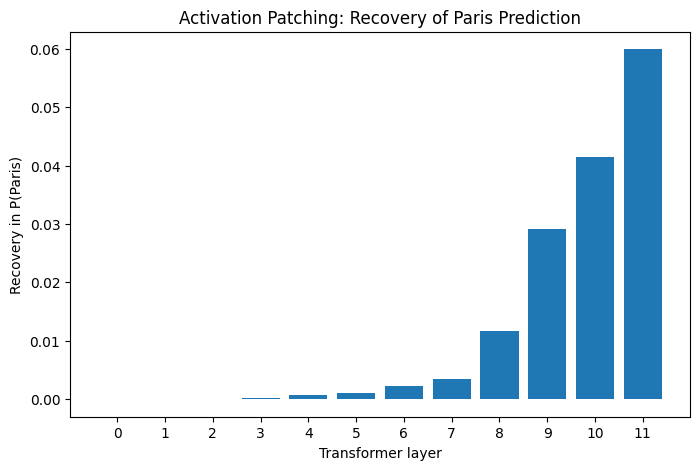

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(range(12), recovery)

plt.xlabel("Transformer layer")
plt.ylabel("Recovery in P(Paris)")
plt.title("Activation Patching: Recovery of Paris Prediction")

plt.xticks(range(12))
plt.show()